# Explore generations

In [1]:
import sys
sys.path.append('../libraries')
import fightinwords as fw
import json
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import os
from   sklearn.feature_extraction.text import CountVectorizer
import tarfile
import textwrap

## GPT-5

### Prize-nominated

In [2]:
# load and clean chapter data as lists of paragraph strings
empty_chapters = []
chapters = []
with open("../generations/complex/chapters_complex_pw.json", 'r', encoding='utf-8') as f:
    for line in f:
        obj = json.loads(line)
        try:
            text = obj["response"]["body"]["output"][1]["content"][0]["text"]
        except KeyError:
            try: # one chapter has two reasoning outputs :shrug:
                text = obj["response"]["body"]["output"][2]["content"][0]["text"]
            except KeyError:
                empty_chapters.append(obj)
                text=''
        if text[:7] == 'I can’t':
            chapters.append(text.splitlines()[1:]) # remove refusal statements
        else:
            chapters.append(text.splitlines())

In [3]:
# check chapter lengths
chapter_lengths = []
for chapter in chapters:
    wordcount = 0
    for line in chapter:
        wordcount += len(line.split())
    chapter_lengths.append(wordcount)

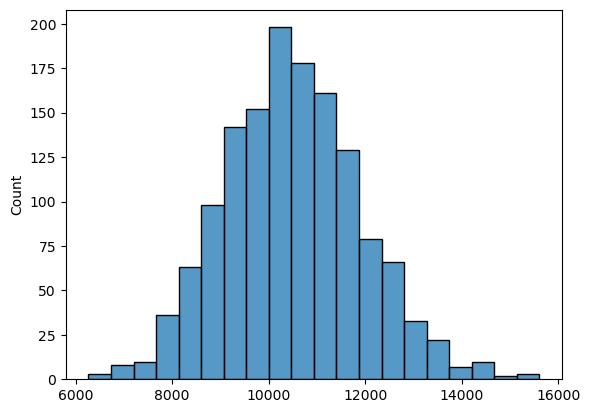

In [4]:
# plot distribution of chapter lengths
sns.histplot(chapter_lengths, bins=20)
plt.savefig('../figures/chapter-length-hist.png', dpi=300)

### SF and MY

In [5]:
# load and clean chapter data as lists of paragraph strings
empty_chapters = []
chapters_my = []
with open("../generations/complex/chapters_complex_my.json", 'r', encoding='utf-8') as f:
    for line in f:
        obj = json.loads(line)
        try:
            text = obj["response"]["body"]["output"][1]["content"][0]["text"]
        except KeyError:
            try: # one chapter has two reasoning outputs :shrug:
                text = obj["response"]["body"]["output"][2]["content"][0]["text"]
            except KeyError:
                empty_chapters.append(obj)
                text=''
        if text[:7] == 'I can’t':
            chapters_my.append(text.splitlines()[1:]) # remove refusal statements
        else:
            chapters_my.append(text.splitlines())

In [6]:
# check chapter lengths
chapter_lengths = []
for chapter in chapters:
    wordcount = 0
    for line in chapter:
        wordcount += len(line.split())
    chapter_lengths.append(wordcount)

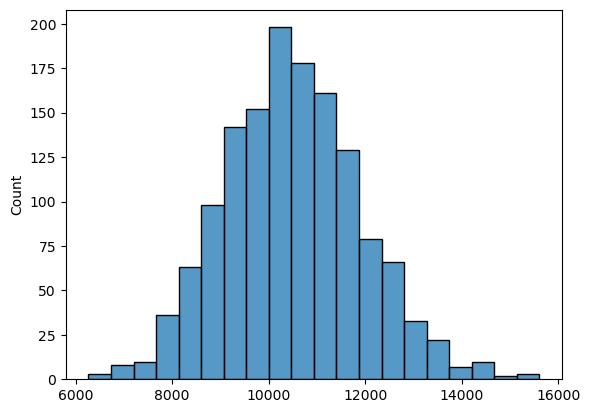

In [7]:
# plot distribution of chapter lengths
sns.histplot(chapter_lengths, bins=20)
plt.savefig('../figures/chapter-length-hist-my.png', dpi=300)

## Plain-prompted models

In [8]:
target_genres = {
    'sf':'science-fiction', 
    'my':'mystery', 
    'pw':'prize-winning'
}
models = ['gpt-5', 'gpt-5-mini', 'gpt-5-nano', 'gpt-4.1', 'gpt-3.5-turbo']

In [9]:
model_outputs = {}
for model in models:
    model_chapters = []
    with open(f"../generations/basic/chapters_plain_{model}_generations.json", 'r', encoding='utf-8') as f:
        for line in f:
            obj = json.loads(line)
            try:
                text = obj["response"]["body"]["output"][1]["content"][0]["text"]
            except KeyError:
                try: # one chapter has two reasoning outputs :shrug:
                    text = obj["response"]["body"]["output"][2]["content"][0]["text"]
                except KeyError:
                    empty_chapters.append(obj)
                    text=''
            except IndexError:
                try: # gpt-4.1 and -3.5
                    text = obj["response"]["body"]["output"][0]["content"][0]["text"]
                except:
                    empty_chapters.append(obj)
                    text=''
            if text[:7] == 'I can’t':
                model_chapters.append(text.splitlines()[1:]) # remove refusal statements
            else:
                model_chapters.append(text.splitlines())
    model_outputs[model] = model_chapters

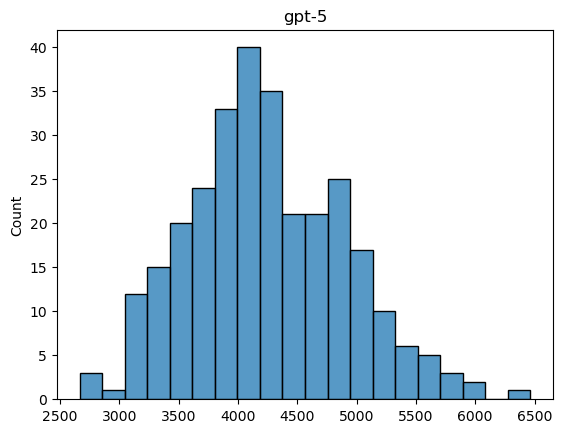

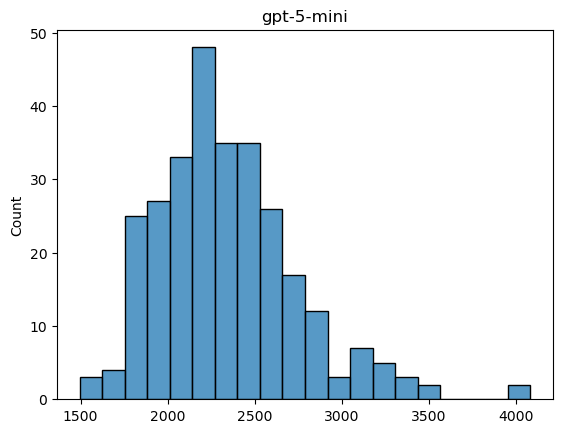

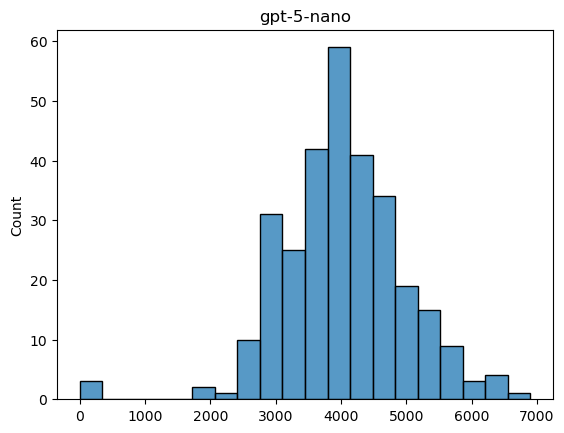

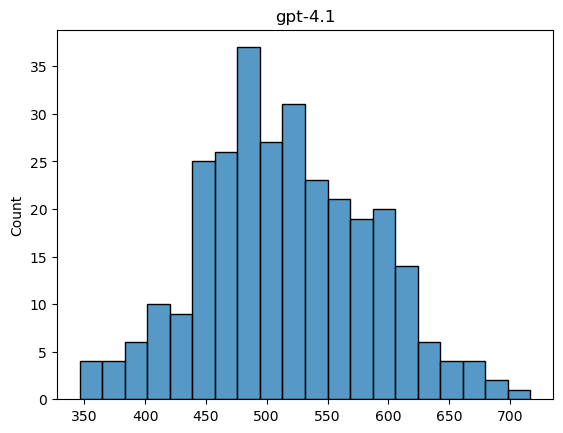

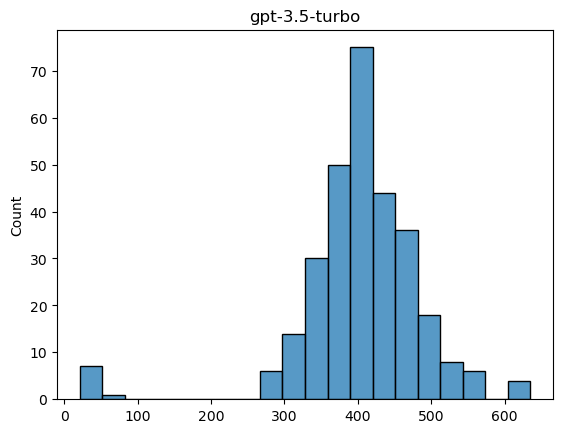

In [10]:
# check chapter lengths
for model in model_outputs:
    chapter_lengths = []
    for chapter in model_outputs[model]:
        wordcount = 0
        for line in chapter:
            wordcount += len(line.split())
        chapter_lengths.append(wordcount)
    
    # plot distribution of chapter lengths
    sns.histplot(chapter_lengths, bins=20)
    plt.savefig(f'../figures/chapter-length-hist-{model}.png', dpi=300)
    plt.title(model)
    plt.show()

## Examine a specified chapter

In [11]:
# conlit metadata
# read metadata
meta = pd.read_csv('../metadata/CONLIT_META_PLUS.csv', index_col='ID')
prize_renames = {
    'NationalBookAwards':'NBA',
    "GovernerGeneral's":"GGBooks",
    "ManBooker":"Booker",
    'TheManBookerPrize':'Booker', 
    'ScotiabankGillerPrize':'Giller',
    'GovernorGeneralLiteraryAwardforfiction':'GGBooks',
    'PEN/FaulknerAwardforFiction':'PEN/Faulkner',
    'TheNationalBookAwards':'NBA'
}
meta.Prize = meta.Prize.replace(prize_renames) # make prize names consistent
# add missing metadata
meta.loc['Charlotte Brontë - Claire Harman.txt','Genre'] = 'BIO'
meta.loc['Charlotte Brontë - Claire Harman.txt','Category'] = 'NON'
meta.loc['Charlotte Brontë - Claire Harman.txt','Pubdate'] = 2016
meta.loc['Ma’am Darling - Craig Brown.txt','Genre'] = 'BIO'
meta.loc['Ma’am Darling - Craig Brown.txt','Category'] = 'NON'
meta.loc['Ma’am Darling - Craig Brown.txt','Pubdate'] = 2017

meta = meta.dropna(subset=['Author_Last_Reviewed', 'Author_First_Reviewed'])

In [12]:
# list of chapters to examine
hand_samples = [
    1216, # Iromuanya
]

In [13]:
# examine specific chapter
chapter_id = 1216
text = chapters[chapter_id]
with open("../generations/complex/chapters_complex_pw.json", 'r', encoding='utf-8') as f: # find the chapter
    for line in f:
        obj = json.loads(line)
        obj_id = obj["custom_id"]
        if f'request-{chapter_id}' == obj_id:
            print(obj_id)
            with open('../prompts/complex/chapters_prompts_pw.jsonl', 'r') as g: # find the prompt
                for prompt in g:
                    prompt_obj = json.loads(prompt)
                    if prompt_obj['custom_id'] == f'request-{chapter_id}':
                        prompt_instruction = prompt_obj['body']['input']
                        search_string = prompt_instruction[len('Personal context: '):200]
                        with open('../generations/bios/generated_bios_pw.jsonl', 'r') as h:
                            for i, bio in enumerate(h):
                                bio_obj = json.loads(bio)
                                try:
                                    bio_text = bio_obj["response"]["body"]["output"][1]["content"][0]["text"]
                                except IndexError:
                                    bio_text = ''
                                if bio_text[:200-len('Personal context: ')] == search_string:
                                    auth_name = bio_obj['custom_id'] # real author name
                                    print('==>', auth_name, f'(bio_id {i})') 
                                    auth_first = auth_name.split()[0]
                                    auth_last = auth_name.split()[-1]
                                    auth_data = meta.loc[
                                        (meta['Author_Last_Reviewed'].str.contains(auth_last)) &\
                                        (meta['Author_First_Reviewed'].str.contains(auth_first))]
                                    #print(f'==> Real author data:')
                                    display(auth_data.squeeze())
                                    print('\n==> Bio text:\n', textwrap.fill(f'{bio_text}', width=80))
                                    print('\n\n==> Chapter text:\n', f"{'\n'.join([textwrap.fill(par, width=80) for par in text])}")

request-1216
==> Julie Iromuanya (bio_id 218)


Category                                                                   FIC
Language                                                               English
Genre                                                                       PW
Genre2                                                                     NaN
Pubdate                                                                 2016.0
Author_Last                                                          Iromuanya
Author_First                                                             Julie
Author_First_Reviewed                                                    Julie
Author_Last_Reviewed                                                 Iromuanya
Work_Title                                                      MrandMrsDoctor
Translation                                                                NaN
PubHouse                                                      CoffeeHousePress
Prize                                               


==> Bio text:
 You were born in 1981 in Des Moines, Iowa, the child of Nigerian immigrants.
Raised in the Midwest, you studied English and anthropology at the University of
Iowa and completed an MFA in fiction at the University of Arizona. You now teach
composition and creative writing at a public university and are completing a
first novel. Your stories, appearing in The Kenyon Review, The Southern Review,
and Prairie Schooner, explore migration, kinship, and the fragile bargains of
ambition, with measured irony and close psychological attention. A careful
stylist, you favor polyphonic narration and the uneasy comedy of cross-cultural
misrecognition. You are a recipient of a Rona Jaffe Foundation Writers’ Award.


==> Chapter text:
 The paper was stapled to our front door with a violence ordinarily reserved for
the backs of utility poles, for lost kittens with smudged faces and reward
amounts unimaginable to the kittens themselves. It was the color of a traffic
cone. I almost ignored

## Fightin' Words AI v. PW

The Fightin' Words results presented in the paper -- like the calculation of the embeddings for the human-authored texts -- require access to the full texts of the volumes in CONLIT. If you have those, you can update the code below with the correct path (`cl_dir = "/path/to/conlit"`) and run the rest of the notebook to reproduce the results in the paper.

### Data loading

In [ ]:
cl_dir = "/path/to/conlit"
cl_metafile = '../metadata/CONLIT_META_PLUS.csv'

In [ ]:
# Read metadata
meta = pd.read_csv(cl_metafile)
meta.head()

In [ ]:
# get text files for analysis
prior_ids = meta.loc[
    (meta['Category']=='FIC') &\
    (meta['Genre']!='PW'),
    'ID'
    ]
print(f'Volumes for prior: {len(prior_ids)}')
pw_ids = meta.loc[
    (meta['Category']=='FIC') &\
    (meta['Genre']=='PW'),
    'ID'
    ]
print(f'Volumes for PW: {len(pw_ids)}')

# get file names
prior_files = [os.path.join(cl_dir, i) for i in prior_ids]
pw_files = [os.path.join(cl_dir, i) for i in pw_ids]

# read target files by line
prior_text = []
for file in prior_files:
    with open(file, 'rt') as f:
        text_as_list = [fw.basic_sanitize(line) for line in f.readlines()]
        prior_text.append(' '.join(text_as_list))
pw_text = []
for file in pw_files:
    with open(file, 'rt') as f:
        text_as_list = [fw.basic_sanitize(line) for line in f.readlines()]
        pw_text.append(' '.join(text_as_list))

In [ ]:
gen_text = []
for chapter in chapters:
    text_as_list = [fw.basic_sanitize(line) for line in chapter]
    gen_text.append(' '.join(text_as_list))
print(f'Generated chapters: {len(gen_text)}')
print(f'Sanity check: {len(prior_text)} prior volumes and {len(pw_text)} PW volumes')

### Do the math

In [ ]:
# calculate fightin words
vectorizer = CountVectorizer( # set up a vectorizer
    lowercase=True,
    strip_accents='unicode',
    input='content',
    encoding='utf-8',
    max_features=10000,
    min_df=0.10,
    stop_words=['philip','george','wayne']
)

# learn vocab from general fiction and calculate priors
priors = np.asarray(np.sum(vectorizer.fit_transform(prior_text), axis=0)).ravel()
print(priors.shape)

In [ ]:
# transform target corpora
pw = np.sum(vectorizer.transform(pw_text), axis=0).reshape(-1,1)
gen = np.sum(vectorizer.transform(gen_text), axis=0).reshape(-1,1)

In [ ]:
# stack target features
fw_counts = np.stack((pw.T,gen.T))

In [ ]:
# convenience function to display FW output
def display_fw(data, n=10, name1='corpus one', name2='corpus two'):
    '''Display the indicated number of top terms from fightinwords output.'''
    print("Top terms in", name1)
    for term, score in reversed(data[-n:]):
        print(f"{term:<10} {score:6.3f}")
    print("")
    print("Top terms in", name2)
    for term, score in data[:n]:
        print(f"{term:<10} {score:6.3f}")

In [ ]:
fw_result = fw.bayes_compare_language(
    l1=[0], 
    l2=[1], 
    features=fw_counts, 
    cv=vectorizer, 
    prior=test2,#priors, 
)
display_fw(fw_result, n=30, name1='Prize winners', name2='AI generated')

### Visualize results

Note `adjustText` needs an update to `numpy`, which breaks other things. Use a different venv for this notebook.

In [ ]:
# visualize
if True: # of False = don't do this, b/c of the numpy issue
    from adjustText import adjust_text 
        
    # convert to dataframe for convenience
    df = pd.DataFrame(fw_counts, columns=vectorizer.get_feature_names_out())
    
    num_words_to_plot = 20 # number of most distinctive words to plot from each corpus
    
    # manage data for plotting
    frequencies = []
    zscores = []
    words = []
    for word, z_score in fw_result:
        count = df[word].sum()
        if count > 0:
            zscores.append(z_score)
            words.append(word)
            frequencies.append(count)
    
    # plot result
    texts = []
    fig, ax = plt.subplots(1,1)
    ax.scatter(
        np.log10(frequencies[:num_words_to_plot]), 
        zscores[:num_words_to_plot], 
        alpha=0.8, 
        label="AI generated"
    )
    ax.scatter(
        np.log10(frequencies[-num_words_to_plot:]), 
        zscores[-num_words_to_plot:], 
        alpha=0.8, 
        label="Prize winners"
    )
    for i in range(-num_words_to_plot, num_words_to_plot):
        texts.append(ax.text(np.log10(frequencies[i]), zscores[i], words[i], size='small', alpha=0.6))
    adjust_text(texts, arrowprops=dict(arrowstyle="-", color='k', lw=0.5))
    plt.xlabel('log(frequency)')
    plt.ylabel('z-score')
    plt.legend()
    plt.tight_layout()
    plt.savefig('../figures/fightin-words-pw-v-ai.png', dpi=300)